# Commercial Waste Zones and Truck Crashes

Working notebook for the pitch in `../README.md`: CWZ was sold partly as a safety measure;\nQueens Central has been live 20 months and refuse-vehicle crashes haven't moved. This\nnotebook runs the analysis the README lays out, in order:\n\n1. Citywide refuse-vehicle crash trend (the top-line claim)\n2. The municipal-vs-private split — **do this before trusting anything zone-level**, per\n   `../NOTES.md` #2. `vehicle_type` does not distinguish DSNY trucks from private carters,\n   and only carters are zoned.\n3. Zone-level panel: crashes indexed to each zone's implementation date, treated vs. control\n4. Enforcement: side-guard mandate violations vs. the waiver counts BIC gave Streetsblog\n\nData ends 2026-06-11 (crashes) / 2026-05-04 (refuse-vehicle rows) — see `../NOTES.md` #1.\nOnly phases 1-3 have any post-period; treat phase 4 (Lower Manhattan) as not-yet-usable.\n\nRun `python ../scripts/fetch_data.py` then `python ../scripts/build_panel.py` first if\n`../out/` doesn't exist yet.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

ROOT = Path("..").resolve()
DATA, OUT, RAW = ROOT / "data", ROOT / "out", ROOT / "raw"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

crashes_by_year = pd.read_csv(DATA / "refuse_crashes_by_year.csv")
rollout = pd.read_csv(DATA / "cwz_rollout.csv", parse_dates=["implementation_date"])
crashes_zoned = pd.read_csv(OUT / "refuse_crashes_zoned.csv", parse_dates=["crash_date", "implementation_date"])
panel = pd.read_csv(OUT / "panel_zone_month.csv", parse_dates=["implementation_date"])
panel["month"] = pd.to_datetime(panel["month"])

CRASH_DATA_ENDS = pd.Timestamp("2026-06-11")
REFUSE_DATA_ENDS = pd.Timestamp("2026-05-04")

print(f"{len(crashes_zoned):,} zoned refuse-vehicle crashes, {len(panel):,} zone-months")
crashes_zoned.head()

5,161 zoned refuse-vehicle crashes, 1,926 zone-months


,collision_id,crash_date,month,borough,latitude,longitude,zone,zone_name,implementation_date,treatment_status,months_since_implementation,post_implementation,refuse_vehicles_in_crash,vehicle_makes,persons_injured,persons_killed,cyclist_injured,cyclist_killed,pedestrians_injured,pedestrians_killed
0,3405829,2016-04-18,2016-04,MANHATTAN,40.720940,-73.995926,MN-1B,Manhattan Southwest,NaT,control,NaN,NaN,1,INTL-TRUCK/BUS,0,0,0,0,0,0
1,3406222,2016-04-13,2016-04,MANHATTAN,40.721275,-73.985880,MN-2,Manhattan Southeast,NaT,control,NaN,NaN,1,MACK-TRUCK/BUS,0,0,0,0,0,0
2,3406282,2016-03-17,2016-03,NaN,40.727130,-73.988754,MN-2,Manhattan Southeast,NaT,control,NaN,NaN,1,VOLV -TRUCK/BUS,0,0,0,0,0,0
3,3406349,2016-04-01,2016-04,MANHATTAN,40.724575,-73.990616,MN-2,Manhattan Southeast,NaT,control,NaN,NaN,1,WHI,1,0,0,0,0,0
4,3406387,2016-04-08,2016-04,MANHATTAN,40.726242,-73.991425,MN-2,Manhattan Southeast,NaT,control,NaN,NaN,1,AUTOC,0,0,0,0,0,0


## 1. Citywide refuse-vehicle crashes, 2016-2026

Pre-verified in `../data/refuse_crashes_by_year.csv`. 2014/2015 are single-record artifacts
(the table starts April 2016) and are dropped. 2026 is a partial year (refuse-vehicle rows
stop 2026-05-04) and shown as a lighter bar rather than annualized — extrapolating a partial
year is how you accidentally manufacture a trend.

2020-2025 range: 393-448, flat within a ~55-crash band
2025 (Queens Central's first live year): 417


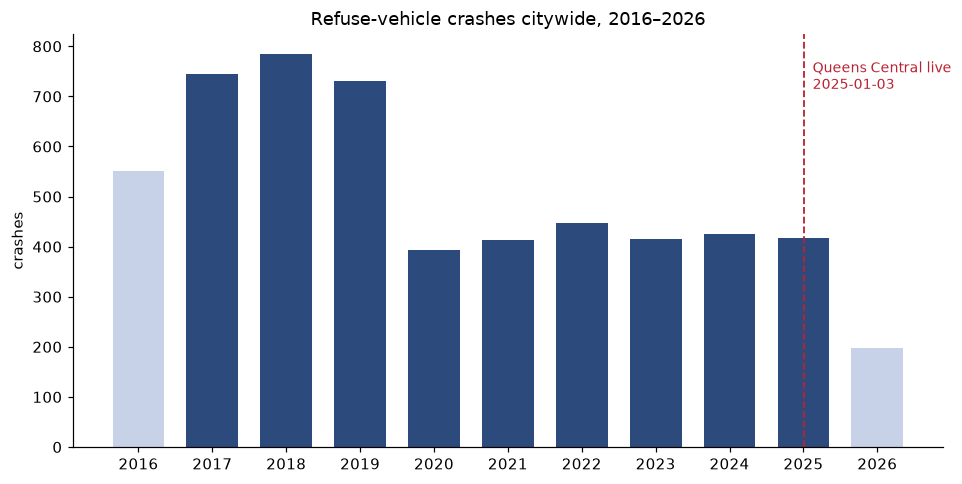

In [14]:
plot_df = crashes_by_year[crashes_by_year["year"] >= 2016].copy()
is_partial = plot_df["note"].fillna("").str.contains("partial")

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = np.where(is_partial, "#c7d2e8", "#2c4a7c")
ax.bar(plot_df["year"], plot_df["crashes_involving_refuse_vehicle"], color=colors, width=0.7)

qn2 = rollout.loc[rollout["zone_codes"].str.contains("QN-2"), "implementation_date"].iloc[0]
ax.axvline(qn2.year + (qn2.dayofyear / 365), color="#b23", ls="--", lw=1.2)
ax.annotate("Queens Central live\n2025-01-03", xy=(qn2.year, plot_df["crashes_involving_refuse_vehicle"].max()),
            xytext=(6, -4), textcoords="offset points", fontsize=9, color="#b23", va="top")

ax.set_title("Refuse-vehicle crashes citywide, 2016–2026")
ax.set_ylabel("crashes")
ax.set_xticks(plot_df["year"])
fig.tight_layout()

peak = crashes_by_year.loc[crashes_by_year["year"].between(2020, 2025), "crashes_involving_refuse_vehicle"]
print(f"2020-2025 range: {peak.min()}-{peak.max()}, flat within a ~55-crash band")
print(f"2025 (Queens Central's first live year): {crashes_by_year.loc[crashes_by_year.year==2025, 'crashes_involving_refuse_vehicle'].iloc[0]}")

## 2. The municipal-vs-private crux

`vehicle_type` lumps DSNY (municipal) trucks in with private carters, but only carters are
zoned under CWZ. Per `../README.md`, this has to be dealt with **before** the zone comparison
means anything — otherwise any effect is diluted by whatever share of refuse-vehicle crashes
are DSNY trucks, which aren't touched by the policy at all.

The only handles in the crash data are `vehicle_make` and `state_registration`. Check whether
that's actually enough to separate the two fleets.

In [15]:
makes = (crashes_zoned["vehicle_makes"].fillna("").str.split(";")
         .explode().str.strip())
makes = makes[makes != ""]
make_counts = makes.value_counts()
make_share = (make_counts / len(crashes_zoned) * 100).round(1)

top = pd.DataFrame({"crashes": make_counts, "pct_of_all_zoned_crashes": make_share}).head(12)
display(top)

mack_share = make_share.get("MACK-TRUCK/BUS", 0) + make_share.get("MACK", 0)
print(f"\nMACK makes alone: {mack_share:.1f}% of zoned crashes")
print("MACK LR is the standard chassis for BOTH the DSNY fleet and most private carters in NYC.")
print("vehicle_make does NOT separate municipal from private here - it's a dead end as a heuristic.")
print("state_registration is similarly uninformative: DSNY plates and commercial plates both")
print("read as ordinary NY registrations in this field.")

,crashes,pct_of_all_zoned_crashes
vehicle_makes,,
MACK-TRUCK/BUS,3015,58.4
PTRB-TRUCK/BUS,266,5.2
MACK,142,2.8
KW-TRUCK/BUS,136,2.6
GLBEN,120,2.3
FRHT-TRUCK/BUS,104,2.0
FORD-TRUCK/BUS,79,1.5
INTL-TRUCK/BUS,43,0.8
WSTR-TRUCK/BUS,31,0.6



MACK makes alone: 61.2% of zoned crashes
MACK LR is the standard chassis for BOTH the DSNY fleet and most private carters in NYC.
vehicle_make does NOT separate municipal from private here - it's a dead end as a heuristic.
state_registration is similarly uninformative: DSNY plates and commercial plates both
read as ordinary NY registrations in this field.


**Finding: the data cannot separate DSNY from private carters.** `vehicle_make` is dominated by
Mack, which both fleets use; `state_registration` is just the plate's issuing state. There is no
usable heuristic in the crash data itself (confirms `../NOTES.md` #2 rather than resolving it).

Two honest paths forward, in order of preference:
- **BIC's licensee roster (`867j-5pgi`)** might carry a vehicle identifier that crash records
  could join on if crash records ever record an operator/plate combination that matches — unread,
  flagged in `../NOTES.md` as unconfirmed structure. Worth a follow-up query before trusting it.
- Failing that, report citywide flatness and the enforcement finding as the primary evidence,
  and present the zone comparison below as an explicitly caveated secondary exhibit, not a claim
  of causal effect. That's what the rest of this section does.

## 3. Zone-level panel: crashes around each zone's implementation date

Only phases 1-3 have any post-period worth showing: Queens Central (QN-2, 17 months),
Bronx East/West (BX-1/BX-2, 6 months), Brooklyn South/Queens Northeast (BK-5/QN-3, 3 months).
Phase 4 (Lower Manhattan) went live 10 days before the data ends and is dropped here. Everything
else is control by construction, not by design — most "control" zones simply haven't been
implemented yet.

In [16]:
USABLE_TREATED = {"QN-2", "BX-1", "BX-2", "BK-5", "QN-3"}  # phases 1-3 only

cz = crashes_zoned[crashes_zoned["crash_date"] <= REFUSE_DATA_ENDS].copy()
cz["is_treated"] = cz["zone"].isin(USABLE_TREATED)
cz["is_phase4"] = cz["zone"] == "MN-1A"

treated = cz[cz["is_treated"]]
pre = treated[treated["post_implementation"] == 0]
post = treated[treated["post_implementation"] == 1]

# Months of pre/post exposure actually observed per zone, so rates are comparable.
zone_span = (rollout.assign(codes=rollout["zone_codes"].str.split(";"))
             .explode("codes").assign(codes=lambda d: d["codes"].str.strip())
             .set_index("codes")["implementation_date"])

def months_of_data(zone, start, end):
    return max(0, (end.year - start.year) * 12 + (end.month - start.month))

rows = []
for z in sorted(USABLE_TREATED):
    impl = zone_span[z]
    pre_months = months_of_data(z, cz["crash_date"].min(), impl)
    post_months = months_of_data(z, impl, REFUSE_DATA_ENDS)
    n_pre = len(pre[pre["zone"] == z])
    n_post = len(post[post["zone"] == z])
    rows.append({
        "zone": z, "implementation_date": impl.date(),
        "pre_crashes": n_pre, "pre_months": pre_months,
        "pre_rate_per_month": round(n_pre / pre_months, 3) if pre_months else np.nan,
        "post_crashes": n_post, "post_months": post_months,
        "post_rate_per_month": round(n_post / post_months, 3) if post_months else np.nan,
    })
zone_table = pd.DataFrame(rows)
display(zone_table)

pooled_pre_rate = zone_table["pre_crashes"].sum() / zone_table["pre_months"].sum()
pooled_post_rate = zone_table["post_crashes"].sum() / zone_table["post_months"].sum()
print(f"\nPooled phases 1-3: {pooled_pre_rate:.3f} crashes/zone-month pre vs "
      f"{pooled_post_rate:.3f} post ({zone_table['pre_crashes'].sum()} pre-crashes over "
      f"{zone_table['pre_months'].sum()} zone-months, {zone_table['post_crashes'].sum()} "
      f"post-crashes over {zone_table['post_months'].sum()} zone-months).")
print("These are counts on a small base - see caveats below before reading anything into the gap.")

,zone,implementation_date,pre_crashes,pre_months,pre_rate_per_month,post_crashes,post_months,post_rate_per_month
0,BK-5,2026-03-01,148,135,1.096,2,2,1.000
1,BX-1,2025-12-01,486,132,3.682,20,5,4.000
2,BX-2,2025-12-01,302,132,2.288,13,5,2.600
3,QN-2,2025-01-03,183,121,1.512,30,16,1.875
4,QN-3,2026-03-01,209,135,1.548,3,2,1.500



Pooled phases 1-3: 2.027 crashes/zone-month pre vs 2.267 post (1328 pre-crashes over 655 zone-months, 68 post-crashes over 30 zone-months).
These are counts on a small base - see caveats below before reading anything into the gap.


Monthly counts per zone-group are almost all 0-3. This is the noise floor NOTES.md warns
about - no single month here can carry a claim either way.


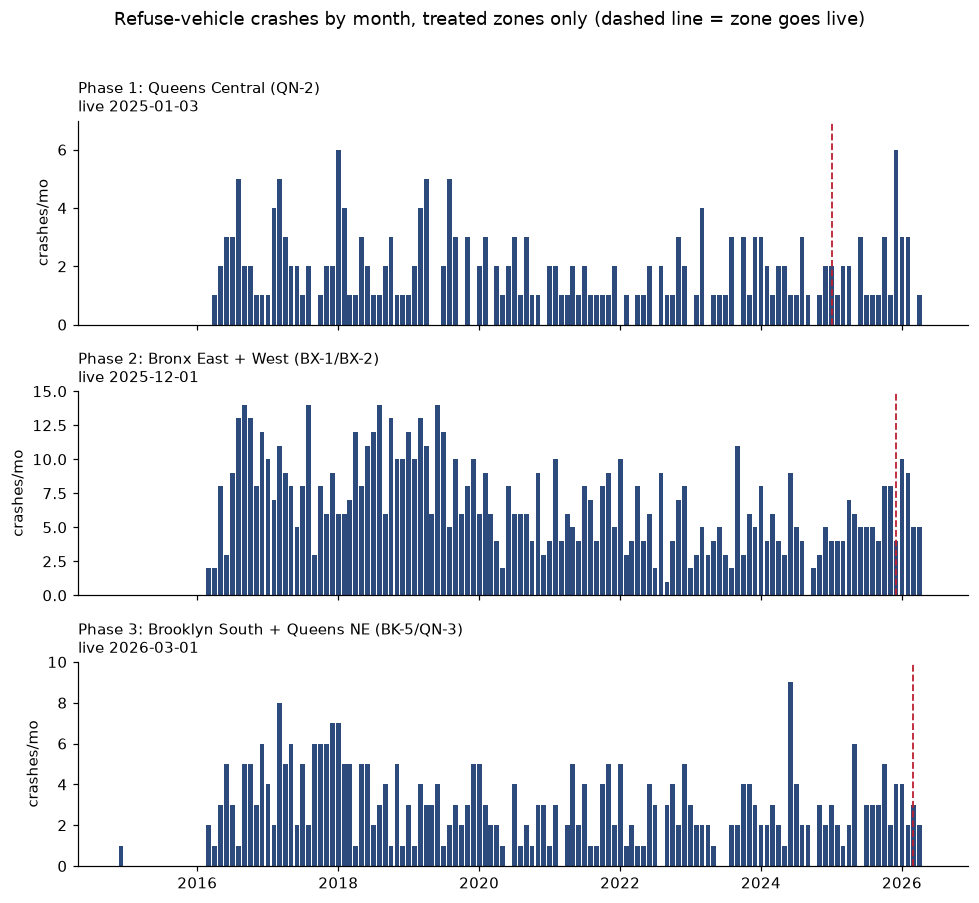

In [17]:
PHASE_GROUPS = {
    "Phase 1: Queens Central (QN-2)\nlive 2025-01-03": ["QN-2"],
    "Phase 2: Bronx East + West (BX-1/BX-2)\nlive 2025-12-01": ["BX-1", "BX-2"],
    "Phase 3: Brooklyn South + Queens NE (BK-5/QN-3)\nlive 2026-03-01": ["BK-5", "QN-3"],
}

fig, axes = plt.subplots(len(PHASE_GROUPS), 1, figsize=(9, 8), sharex=True)
for ax, (label, zones) in zip(axes, PHASE_GROUPS.items()):
    sub = cz[cz["zone"].isin(zones)]
    monthly = sub.groupby(sub["crash_date"].dt.to_period("M")).size()
    monthly.index = monthly.index.to_timestamp()
    full_idx = pd.date_range(cz["crash_date"].min().to_period("M").to_timestamp(),
                              REFUSE_DATA_ENDS.to_period("M").to_timestamp(), freq="MS")
    monthly = monthly.reindex(full_idx, fill_value=0)
    ax.bar(monthly.index, monthly.values, width=25, color="#2c4a7c")
    impl = zone_span[zones[0]]
    ax.axvline(impl, color="#b23", ls="--", lw=1.2)
    ax.set_ylabel("crashes/mo")
    ax.set_title(label, fontsize=10, loc="left")
    ax.set_ylim(0, max(3, monthly.max() + 1))

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Refuse-vehicle crashes by month, treated zones only (dashed line = zone goes live)", y=1.02)
fig.tight_layout()
print("Monthly counts per zone-group are almost all 0-3. This is the noise floor NOTES.md warns")
print("about - no single month here can carry a claim either way.")

## 4. Enforcement: mandate violations vs. waivers

The second thread. Side guards have been mandated since 2015 (Local Law 56) with a 2023
compliance deadline. `../data/bic_sideguard_rules.csv` classifies every BIC rule text that
mentions side guards — only two are the mandate itself; the rest are inspection/compliance
rules that happen to reference side guards among a dozen other things. **Do not report the
1,662 raw `%SIDE GUARD%` text match as mandate enforcement** — see `../NOTES.md` #8.

Waiver counts (~312 this year, 572 last year) are BIC's statement to Streetsblog, not in Open
Data — flagged `unverified` in `../data/verified_figures.csv`. They're shown for contrast, not
as a verified figure.

,violation_count
category,
inspection_6mo,737
inspection_daily,694
general_compliance,423
inspection_6mo_cwz,184
mandate,47
worker_notice,4



47 side-guard MANDATE violations total, all-time, out of 2,089 rows mentioning side guards in any rule text.
The other categories (inspection, general compliance, worker notice) are not the mandate -
they're rules that happen to list side guards among many other inspected items.


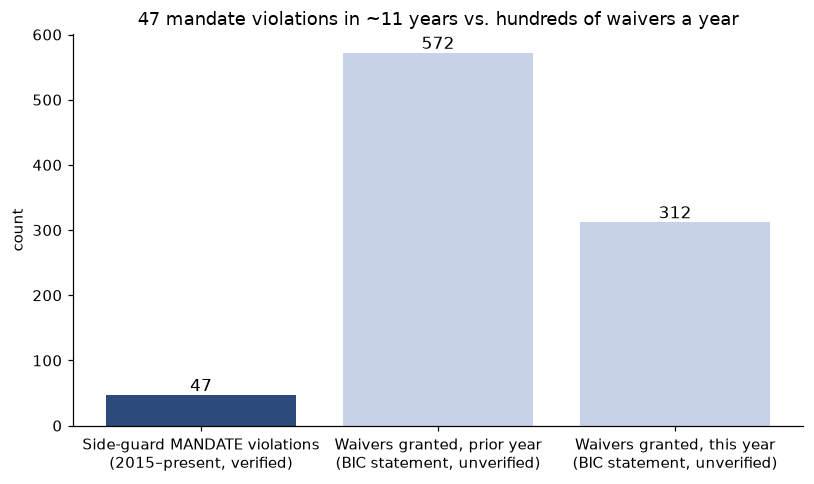

In [18]:
rules = pd.read_csv(DATA / "bic_sideguard_rules.csv")
by_category = rules.groupby("category")["violation_count"].sum().sort_values(ascending=False)
display(by_category.to_frame("violation_count"))

mandate_violations = int(rules.loc[rules["category"] == "mandate", "violation_count"].sum())
assert mandate_violations == 47, "should reconcile to the verified figure"

compare = pd.DataFrame({
    "label": ["Side-guard MANDATE violations\n(2015–present, verified)",
              "Waivers granted, prior year\n(BIC statement, unverified)",
              "Waivers granted, this year\n(BIC statement, unverified)"],
    "value": [mandate_violations, 572, 312],
    "verified": ["verified", "unverified", "unverified"],
})
fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = compare["verified"].map({"verified": "#2c4a7c", "unverified": "#c7d2e8"})
bars = ax.bar(compare["label"], compare["value"], color=colors)
for b, v in zip(bars, compare["value"]):
    ax.annotate(f"{v:,}", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom", fontsize=11)
ax.set_ylabel("count")
ax.set_title("47 mandate violations in ~11 years vs. hundreds of waivers a year")
fig.tight_layout()

print(f"\n{mandate_violations} side-guard MANDATE violations total, all-time, out of "
      f"{int(rules['violation_count'].sum()):,} rows mentioning side guards in any rule text.")
print("The other categories (inspection, general compliance, worker notice) are not the mandate -")
print("they're rules that happen to list side guards among many other inspected items.")

## Where this stands

- **Citywide**: flat, 393-448 crashes/year from 2020-2025, no visible break at Queens Central's
  2025-01-03 go-live. This is the strongest, most defensible number in the bundle.
- **Zone-level**: pooled across the five zones with any post-period (phases 1-3), the raw crash
  rate is 2.03/zone-month pre-implementation vs. 2.27/zone-month post — essentially flat, if
  anything a touch higher, on 1,328 pre-crashes over 655 zone-months and 68 post-crashes over 30
  zone-months. Per zone: QN-2 (the 17-month flagship) goes from 1.51 to 1.88/month; BX-1, BX-2
  and QN-3 are flat-to-up; only BK-5 (3 months of post-data) ticks down. **Nothing here shows a
  decline** — consistent with the pitch's "flat to nothing" framing, not the version where CWZ
  quietly worked. But the municipal/private split needed to make this comparison mean anything
  isn't resolvable from the crash data (section 2), and monthly counts per zone are mostly 0-3 —
  too small to support a causal claim either way. Report it as "no decline visible," not as a
  measured null effect.
- **Enforcement**: 47 mandate violations since 2015 against BIC's own claim of hundreds of
  waivers per year is real and verified on the violations side. The waiver side rests on an
  agency statement, not a dataset — the single highest-value follow-up is the FOIL request in
  `../NOTES.md`.

Next, in priority order (see `../NOTES.md` for the full list):
1. FOIL the BIC waiver list (grant date, licensee, BIC number, vehicle id, grounds, 2022-present).
2. Check whether `867j-5pgi` (BIC licensee roster) can join to crash records on any field, to
   get a real shot at the municipal/private split.
3. Read the Council oversight hearing (2025-04-23) and DSNY's implementation-plan appendix for
   a quantified safety target CWZ was supposed to hit — right now the piece can say crashes are
   flat but not that a specific goal was missed.
4. Check whether the share of blank/`OTHER` `vehicle_type` values drifted over the study window
   (NOTES.md #3) before attributing any apparent trend to policy rather than reporting practice.